

Признаки строим по логу событий events за окно наблюдения куки, дальше
сравниваем CatBoost, LightGBM и XGBoost, каждый подбираем через Optuna, и в конце
блендим все три.

In [1]:
!pip install optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 22.8 MB/s eta 0:00:00


In [2]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 5.8 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import optuna
import shap

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer

import sys
sys.path.append('.')
from metric import precision_at_recall

RANDOM_STATE = 55

In [4]:
# кастомная метрика задачи как sklearn-скорер, чтобы использовать в cross_val_score
precision_scorer = make_scorer(precision_at_recall, response_method='predict_proba')

## Загрузка данных

In [5]:
train = pd.read_csv('data/train.csv', parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'])
test = pd.read_csv('data/test.csv', parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'])
events = pd.read_csv('data/events.csv.gz', parse_dates=['event_ts'])

In [6]:
print(train.shape, test.shape, events.shape)
print(train['target'].value_counts(normalize=True))

(11091, 5) (4909, 4) (328905, 14)
target
0    0.918943
1    0.081057
Name: proportion, dtype: float64


Ботов 8% от всех кук - сильный дисбаланс, поэтому дальше в оптуне в oof будем стратифай фолды брать, а метрика задачи (Precision@Recall >= 0.70)
это и так учитывает

## Проверка данных

In [7]:
print('дубликатов строк в events:', events.duplicated().sum())
events = events.drop_duplicates().sort_values(['cookie_id', 'event_ts']).reset_index(drop=True)

дубликатов строк в events: 4863


In [52]:
events_check = events.merge(train[['cookie_id', 'window_start_ts', 'window_end_ts']], on='cookie_id')
in_window_check = (events_check['event_ts'] >= events_check['window_start_ts']) & \
                   (events_check['event_ts'] < events_check['window_end_ts'])

captcha_in = events_check.loc[in_window_check, 'event_name'].eq('captcha_shown').mean()
captcha_out = events_check.loc[~in_window_check, 'event_name'].eq('captcha_shown').mean()
print('captcha_shown внутри окна:', round(captcha_in, 4), 'вне окна:', round(captcha_out, 4))

captcha_shown внутри окна: 0.0 вне окна: 0.1948


captcha_shown почти не встречается внутри окна и почти весь - после него, то есть
это реакция системы на уже подозрительную куку, случившаяся позже. Значит признаки
строим только по событиям строго внутри [window_start_ts, window_end_ts], иначе
получим утечку таргета из будущего. Также user_agent не берём напрямую - версия
браузера у ботов и у людей почти не отличается, это шум, котрый может привезти к переобучени. Из user_agent берем только платформу

## Признаки

Строим один раз сразу для train + test (агрегация событий по cookie_id, каждая кука считается независимо без утчки), потом
разъединяем обратно

In [9]:
all_meta = pd.concat([
    train[['cookie_id', 'cookie_created_at', 'window_start_ts', 'window_end_ts']],
    test[['cookie_id', 'cookie_created_at', 'window_start_ts', 'window_end_ts']],
], ignore_index=True)

print('всего кук:', len(all_meta))

всего кук: 16000


In [10]:
ev = events.merge(all_meta[['cookie_id', 'window_start_ts', 'window_end_ts']], on='cookie_id')
in_window = (ev['event_ts'] >= ev['window_start_ts']) & (ev['event_ts'] < ev['window_end_ts'])
ev = ev[in_window].copy()

print('событий внутри окна:', ev.shape)

событий внутри окна: (283833, 16)


In [11]:
def normalize_platform(p):
    p = str(p).lower()
    if p in ('desktop', 'web'):
        return 'web'
    if p == 'android':
        return 'android'
    if p in ('ios', 'iphone'):
        return 'ios'
    return p


ev['platform_norm'] = ev['platform'].apply(normalize_platform)
ev['hour'] = ev['event_ts'].dt.hour
ev['is_night'] = ev['hour'] < 6

In [12]:
g = ev.groupby('cookie_id')

feats = pd.DataFrame(index=g.size().index)
feats['n_events'] = g.size()

Считаем сколько событий каждого типа было у каждой куки.


In [13]:
event_counts = ev.pivot_table(index='cookie_id', columns='event_name', values='event_ts', aggfunc='count', fill_value=0)
event_counts.columns = ['cnt_' + c for c in event_counts.columns]

feats = feats.join(event_counts)

Переводим абсолютные счётчики в доли от общего числа событий куки, так признак не зависит от общей активности куки.

In [14]:
for c in event_counts.columns:
    feats[c.replace('cnt_', 'share_')] = feats[c] / feats['n_events']

Разнообразие того, что смотрит кука - количество событий, сколько разных объявлений, категорий, запросов

In [15]:
feats['item_nunique'] = g['item_id'].nunique()
feats['category_nunique'] = g['item_category'].nunique()
feats['location_nunique'] = g['item_location'].nunique()
feats['seller_type_nunique'] = g['seller_type'].nunique()
feats['search_query_nunique'] = g['search_query'].nunique()
feats['search_page_max'] = g['search_page'].max()
feats['search_page_mean'] = g['search_page'].mean()
feats['ua_nunique'] = g['user_agent'].nunique()

Интервалы между кликами, число сессий, ночная активность

In [16]:
span = g['event_ts'].agg(lambda s: (s.max() - s.min()).total_seconds())
feats['session_span_sec'] = span
feats['events_per_sec'] = (feats['n_events'] / feats['session_span_sec'].replace(0, np.nan)).fillna(0)

Статистики интервалов между соседними событиями (среднее/разброс/минимум/коэффициент вариации), маленький разброс похож на скрипт, большой - на человека.

In [17]:
def iet_stats(s):
    gaps = s.sort_values().diff().dt.total_seconds().dropna()
    if len(gaps) == 0:
        return pd.Series({'iet_mean': np.nan, 'iet_std': np.nan, 'iet_min': np.nan})
    std = gaps.std() if len(gaps) > 1 else 0.0
    return pd.Series({'iet_mean': gaps.mean(), 'iet_std': std, 'iet_min': gaps.min()})


iet = g['event_ts'].apply(iet_stats).unstack()
iet['iet_cv'] = iet['iet_std'] / iet['iet_mean']
feats = feats.join(iet)

разбиваем поток по паузам больше 30 минут, доля ночных событий и разнообразие часов активности

In [18]:
feats['n_sessions'] = g['event_ts'].apply(lambda s: (s.sort_values().diff().dt.total_seconds() > 1800).sum() + 1)
feats['night_share'] = g['is_night'].mean()
feats['hour_nunique'] = g['hour'].nunique()

Поведение курсора

Есть ли вообще координаты курсора у куки и насколько они разбросаны

In [19]:
feats['pointer_present_share'] = g['pointer_x'].apply(lambda s: s.notna().mean())
feats['pointer_x_std'] = g['pointer_x'].std()
feats['pointer_y_std'] = g['pointer_y'].std()

Средняя и разброс дистанции между соседними положениями курсора, резкие одинаковые прыжки больше похожи на поведение бота.

In [20]:
def pointer_step_stats(d):
    d = d.dropna(subset=['pointer_x', 'pointer_y']).sort_values('event_ts')
    dx = d['pointer_x'].diff()
    dy = d['pointer_y'].diff()
    dist = np.sqrt(dx ** 2 + dy ** 2)
    return pd.Series({'pointer_step_mean': dist.mean(), 'pointer_step_std': dist.std()})


pointer_steps = ev.groupby('cookie_id')[['pointer_x', 'pointer_y', 'event_ts']].apply(pointer_step_stats)
feats = feats.join(pointer_steps)

In [21]:
feats['item_per_event'] = feats['item_nunique'] / feats['n_events'].replace(0, np.nan)
feats['category_per_item'] = feats['category_nunique'] / feats['item_nunique'].replace(0, np.nan)
feats['location_per_item'] = feats['location_nunique'] / feats['item_nunique'].replace(0, np.nan)

сколько просмотров объявлений на один поиск, сколько пролистываний фото на просмотр, доля контактных действий (звонок/чат/сообщение) от всех событий.

In [22]:
view = feats.get('cnt_item_view', pd.Series(0, index=feats.index))
search = feats.get('cnt_search_results_view', pd.Series(0, index=feats.index))
photo = feats.get('cnt_photo_swipe', pd.Series(0, index=feats.index))
contact = (feats.get('cnt_contact_phone_show', pd.Series(0, index=feats.index))
           + feats.get('cnt_contact_chat_open', pd.Series(0, index=feats.index))
           + feats.get('cnt_contact_message_sent', pd.Series(0, index=feats.index)))

feats['view_search_ratio'] = view / search.replace(0, np.nan)
feats['photo_per_view'] = photo / view.replace(0, np.nan)
feats['contact_share'] = contact / feats['n_events'].replace(0, np.nan)

Платформа, на которой кука была активна чаще всего

In [23]:
top_platform = ev.groupby('cookie_id')['platform_norm'].agg(lambda s: s.value_counts().idxmax())
feats['top_platform'] = top_platform

Добавляем куки, у которых вообще не было событий в окне (иначе они выпали бы из таблицы), считаем возраст куки на момент начала окна и заполняем нулём число событий у кук без активности.

In [24]:
all_meta_idx = all_meta.set_index('cookie_id')
feats = feats.reindex(all_meta_idx.index)

feats['account_age_days'] = (all_meta_idx['window_start_ts'] - all_meta_idx['cookie_created_at']).dt.total_seconds() / 86400
feats['n_events'] = feats['n_events'].fillna(0)

feats = feats.reset_index().rename(columns={'index': 'cookie_id'})
print('признаков:', feats.shape[1] - 1)

признаков: 49


## Собираем train И test

In [25]:
train_features = train[['cookie_id', 'target']].merge(feats, on='cookie_id', how='left')
test_features = test[['cookie_id']].merge(feats, on='cookie_id', how='left')

train_features['top_platform'] = train_features['top_platform'].fillna('unknown')
test_features['top_platform'] = test_features['top_platform'].fillna('unknown')

feature_cols = [c for c in train_features.columns if c not in ('cookie_id', 'target')]
print('признаков в модели:', len(feature_cols))

признаков в модели: 49


Для catboost отсавляем категориальные признаки, для остальных кодируем one-hot энкодингом.

In [26]:
X_cat = train_features[feature_cols]
X_dummies = pd.get_dummies(train_features[feature_cols])

X_test_cat = test_features[feature_cols]
X_test_dummies = pd.get_dummies(test_features[feature_cols])
X_test_dummies = X_test_dummies.reindex(columns=X_dummies.columns, fill_value=0)

y = train_features['target']

cat_features = ['top_platform']

In [27]:
def get_oof(model_fn, X, y, cv=5):
    oof = np.zeros(len(y))
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE)
    for train_idx, valid_idx in skf.split(X, y):
        model = model_fn()
        model.fit(X.iloc[train_idx], y.iloc[train_idx])
        oof[valid_idx] = model.predict_proba(X.iloc[valid_idx])[:, 1]
    return oof

## CatBoost

Подбираем параметры через Optuna: минимизируем precision_at_recall через precisio_scorer

In [30]:
def objective_cat(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 300, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.1),
        'depth': trial.suggest_int('depth', 4, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'random_seed': RANDOM_STATE,
    }
    model = CatBoostClassifier(**params, verbose=False)
    score = cross_val_score(model, X_cat, y, cv=3,params={'cat_features': cat_features}, scoring=precision_scorer).mean()
    return score

In [31]:
study_cat = optuna.create_study(direction='maximize')
study_cat.optimize(objective_cat, n_trials=15)

print('лучший score на CV:', study_cat.best_value)
print('лучшие параметры:', study_cat.best_params)

[I 2026-09-20 17:27:59,959] A new study created in memory with name: no-name-480a9b57-e8f0-43a3-820e-057dbfccb649
[I 2026-09-20 17:28:28,054] Trial 0 finished with value: 0.697373056329277 and parameters: {'iterations': 594, 'learning_rate': 0.035113333574330025, 'depth': 4, 'l2_leaf_reg': 6.440168898312219}. Best is trial 0 with value: 0.697373056329277.
[I 2026-09-20 17:29:28,912] Trial 1 finished with value: 0.6832613065587884 and parameters: {'iterations': 746, 'learning_rate': 0.05063728126063817, 'depth': 7, 'l2_leaf_reg': 5.290584533548422}. Best is trial 0 with value: 0.697373056329277.
[I 2026-09-20 17:29:47,625] Trial 2 finished with value: 0.6840107062725588 and parameters: {'iterations': 488, 'learning_rate': 0.08941379026945435, 'depth': 4, 'l2_leaf_reg': 8.121048883042508}. Best is trial 0 with value: 0.697373056329277.
[I 2026-09-20 17:31:34,450] Trial 3 finished with value: 0.6806740314174533 and parameters: {'iterations': 769, 'learning_rate': 0.06428968675361955, 'dep

лучший score на CV: 0.708658103780055
лучшие параметры: {'iterations': 713, 'learning_rate': 0.06630579782141742, 'depth': 4, 'l2_leaf_reg': 7.074708379257773}


In [32]:
def make_cat():
    return CatBoostClassifier(**study_cat.best_params, cat_features=cat_features,
                               random_seed=RANDOM_STATE, verbose=False)


oof_cat = get_oof(make_cat, X_cat, y)
score_cat = precision_at_recall(y.values, oof_cat)
print('CatBoost, precision@recall>=0.70 (OOF):', round(score_cat, 4))

CatBoost, precision@recall>=0.70 (OOF): 0.6731


## LightGBM

In [33]:
def objective_lgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.1),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'num_leaves': trial.suggest_int('num_leaves', 15, 63),
        'reg_lambda': trial.suggest_float('reg_lambda', 1, 10),
        'random_state': RANDOM_STATE,
    }
    model = LGBMClassifier(**params, verbose=-1)
    score = cross_val_score(model, X_dummies, y, cv=3, scoring=precision_scorer).mean()
    return score

In [34]:
study_lgb = optuna.create_study(direction='maximize')
study_lgb.optimize(objective_lgb, n_trials=15)

print('лучший score на CV:', study_lgb.best_value)
print('лучшие параметры:', study_lgb.best_params)

[I 2026-09-20 17:38:01,787] A new study created in memory with name: no-name-2501440c-d082-46da-b829-4fe65c6a0fc6
[I 2026-09-20 17:38:17,910] Trial 0 finished with value: 0.6807670409439757 and parameters: {'n_estimators': 705, 'learning_rate': 0.0809107127558325, 'max_depth': 8, 'num_leaves': 59, 'reg_lambda': 4.657653748121525}. Best is trial 0 with value: 0.6807670409439757.
[I 2026-09-20 17:38:34,858] Trial 1 finished with value: 0.6675057050789537 and parameters: {'n_estimators': 864, 'learning_rate': 0.05549260591560083, 'max_depth': 8, 'num_leaves': 39, 'reg_lambda': 8.04332573767362}. Best is trial 0 with value: 0.6807670409439757.
[I 2026-09-20 17:38:40,252] Trial 2 finished with value: 0.6369692251107045 and parameters: {'n_estimators': 537, 'learning_rate': 0.08596025757161195, 'max_depth': 5, 'num_leaves': 27, 'reg_lambda': 3.60149589549102}. Best is trial 0 with value: 0.6807670409439757.
[I 2026-09-20 17:38:45,913] Trial 3 finished with value: 0.6800119984094882 and param

лучший score на CV: 0.6860996575029
лучшие параметры: {'n_estimators': 474, 'learning_rate': 0.06524266913361887, 'max_depth': 8, 'num_leaves': 62, 'reg_lambda': 9.65325282937306}


In [35]:
def make_lgb():
    return LGBMClassifier(**study_lgb.best_params, random_state=RANDOM_STATE, verbose=-1)


oof_lgb = get_oof(make_lgb, X_dummies, y)
score_lgb = precision_at_recall(y.values, oof_lgb)
print('LightGBM, precision@recall>=0.70 (OOF):', round(score_lgb, 4))

LightGBM, precision@recall>=0.70 (OOF): 0.6429


## XGBoost

In [36]:
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.1),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'reg_lambda': trial.suggest_float('reg_lambda', 1, 10),
        'random_state': RANDOM_STATE,
    }
    model = XGBClassifier(**params, eval_metric='logloss')
    score = cross_val_score(model, X_dummies, y, cv=3, scoring=precision_scorer).mean()
    return score

In [37]:
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=15)

print('лучший score на CV:', study_xgb.best_value)
print('лучшие параметры:', study_xgb.best_params)

[I 2026-09-20 17:40:36,481] A new study created in memory with name: no-name-4b06b6f3-e91b-49a5-9aae-c7e02c8780aa
[I 2026-09-20 17:41:00,075] Trial 0 finished with value: 0.6893497438965914 and parameters: {'n_estimators': 564, 'learning_rate': 0.055186522562242726, 'max_depth': 8, 'reg_lambda': 3.9265422061424773}. Best is trial 0 with value: 0.6893497438965914.
[I 2026-09-20 17:41:13,553] Trial 1 finished with value: 0.624878266211195 and parameters: {'n_estimators': 701, 'learning_rate': 0.06782198991854319, 'max_depth': 5, 'reg_lambda': 2.3791863970548635}. Best is trial 0 with value: 0.6893497438965914.
[I 2026-09-20 17:41:22,904] Trial 2 finished with value: 0.6585654484034035 and parameters: {'n_estimators': 389, 'learning_rate': 0.054110239458509526, 'max_depth': 5, 'reg_lambda': 9.093028058878955}. Best is trial 0 with value: 0.6893497438965914.
[I 2026-09-20 17:41:50,972] Trial 3 finished with value: 0.685021571998394 and parameters: {'n_estimators': 751, 'learning_rate': 0.0

лучший score на CV: 0.6987365705890886
лучшие параметры: {'n_estimators': 597, 'learning_rate': 0.03542446301863986, 'max_depth': 8, 'reg_lambda': 3.2489498809702932}


In [38]:
def make_xgb():
    return XGBClassifier(**study_xgb.best_params, eval_metric='logloss', random_state=RANDOM_STATE)


oof_xgb = get_oof(make_xgb, X_dummies, y)
score_xgb = precision_at_recall(y.values, oof_xgb)
print('XGBoost, precision@recall>=0.70 (OOF):', round(score_xgb, 4))

XGBoost, precision@recall>=0.70 (OOF): 0.6204


## Сравнение моделей

In [39]:
results = pd.DataFrame({
    'model': ['CatBoost', 'LightGBM', 'XGBoost'],
    'precision_at_recall': [score_cat, score_lgb, score_xgb],
}).sort_values('precision_at_recall', ascending=False)

results

,model,precision_at_recall
0,CatBoost,0.673077
1,LightGBM,0.642857
2,XGBoost,0.620352


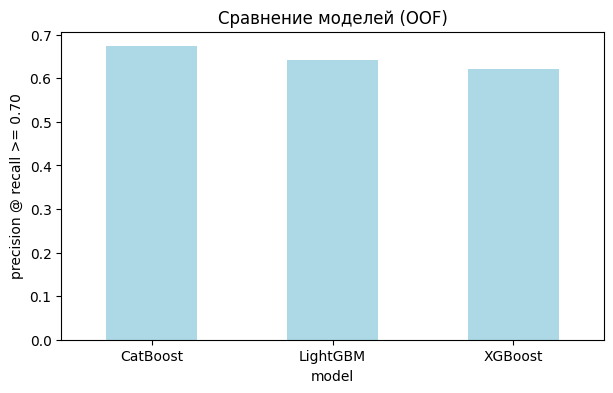

In [40]:
results.plot(x='model', y='precision_at_recall', kind='bar', figsize=(7, 4), color='lightblue', legend=False)
plt.ylabel('precision @ recall >= 0.70')
plt.title('Сравнение моделей (OOF)')
plt.xticks(rotation=0)
plt.show()

## Блендинг
Кетбуст XGBoost и лайтGBM по разному строят деревья, их блендинг может дать прирост отночительно одного кетбуста.
Веса блендинга подбираем тоже через Optuna, по тем же OOF-предсказаниям

In [41]:
def objective_blend(trial):
    w_cat = trial.suggest_float('w_cat', 0, 1)
    w_lgb = trial.suggest_float('w_lgb', 0, 1)
    w_xgb = trial.suggest_float('w_xgb', 0, 1)
    w_sum = w_cat + w_lgb + w_xgb + 1e-9

    blend = (w_cat * oof_cat + w_lgb * oof_lgb + w_xgb * oof_xgb) / w_sum
    return precision_at_recall(y.values, blend)

In [42]:
study_blend = optuna.create_study(direction='maximize')
study_blend.optimize(objective_blend, n_trials=30)

print('лучший score блендинга:', study_blend.best_value)
print('лучшие веса:', study_blend.best_params)

[I 2026-09-20 17:46:39,052] A new study created in memory with name: no-name-87a24825-6eee-451c-9068-bad3b20a22d4
[I 2026-09-20 17:46:39,065] Trial 0 finished with value: 0.6659619450317125 and parameters: {'w_cat': 0.7445878845519508, 'w_lgb': 0.6670472977837839, 'w_xgb': 0.9304437525542109}. Best is trial 0 with value: 0.6659619450317125.
[I 2026-09-20 17:46:39,070] Trial 1 finished with value: 0.6621196222455404 and parameters: {'w_cat': 0.44520895632618407, 'w_lgb': 0.6096134951968708, 'w_xgb': 0.4658195861762118}. Best is trial 0 with value: 0.6659619450317125.
[I 2026-09-20 17:46:39,075] Trial 2 finished with value: 0.6695005313496281 and parameters: {'w_cat': 0.7006963698743385, 'w_lgb': 0.527051054867836, 'w_xgb': 0.9407111918908603}. Best is trial 2 with value: 0.6695005313496281.
[I 2026-09-20 17:46:39,081] Trial 3 finished with value: 0.6555671175858481 and parameters: {'w_cat': 0.3227562191849538, 'w_lgb': 0.40474055119157293, 'w_xgb': 0.8803520537460614}. Best is trial 2 w

лучший score блендинга: 0.6825053995680346
лучшие веса: {'w_cat': 0.9895740544100167, 'w_lgb': 0.6746068913353447, 'w_xgb': 0.6577538586161192}


In [43]:
w = study_blend.best_params
w_sum = w['w_cat'] + w['w_lgb'] + w['w_xgb'] + 1e-9

best_single = max(score_cat, score_lgb, score_xgb)
print('лучшая одиночная модель:', round(best_single, 4))
print('блендинг:', round(study_blend.best_value, 4))

use_blend = study_blend.best_value > best_single + 0.005
print('используем блендинг в финале:', use_blend)

лучшая одиночная модель: 0.6731
блендинг: 0.6825
используем блендинг в финале: True


## Финальные модели

OOF использовались только для честной оценки качества и весов блендинга.
Для предсказаний на test дообучаем каждую модель на всём train-датасете.

In [44]:
final_cat = make_cat()
final_cat.fit(X_cat, y)
pred_test_cat = final_cat.predict_proba(X_test_cat)[:, 1]

In [45]:
final_lgb = make_lgb()
final_lgb.fit(X_dummies, y)
pred_test_lgb = final_lgb.predict_proba(X_test_dummies)[:, 1]

In [46]:
final_xgb = make_xgb()
final_xgb.fit(X_dummies, y)
pred_test_xgb = final_xgb.predict_proba(X_test_dummies)[:, 1]

## Важность признаков

Точный SHAP от финальной модели CatBoost через библиотеку `shap`
(`shap.TreeExplainer`).

In [47]:
explainer = shap.TreeExplainer(final_cat)
shap_values = explainer.shap_values(X_cat)

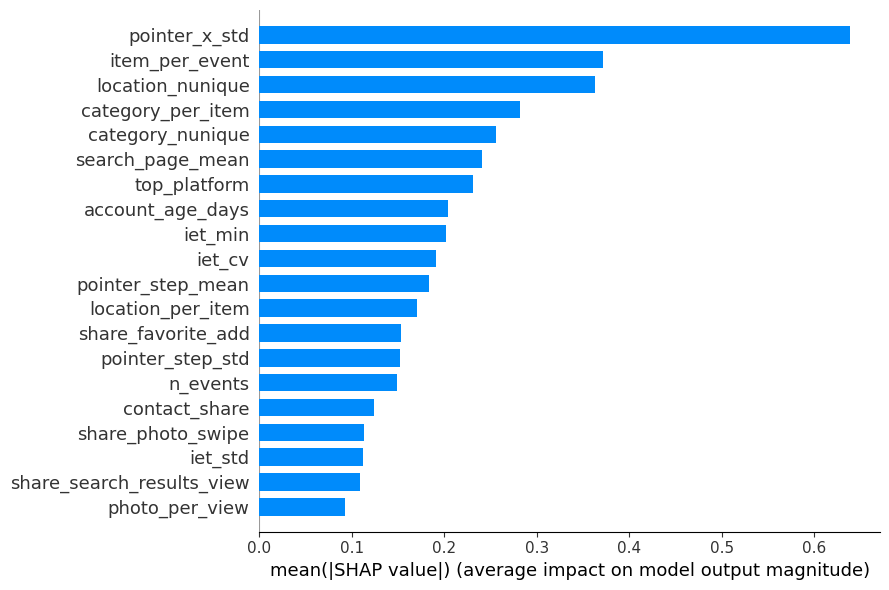

In [48]:
shap.summary_plot(shap_values, X_cat, plot_type='bar', plot_size=(9, 6))

## Submission

In [51]:
test_pred = (w['w_cat'] * pred_test_cat + w['w_lgb'] * pred_test_lgb + w['w_xgb'] * pred_test_xgb) / w_sum

In [50]:
submission = pd.DataFrame({'cookie_id': test_features['cookie_id'], 'score': test_pred})
assert len(submission) == len(test) and submission['score'].between(0, 1).all()
submission.to_csv('submission.csv', index=False)
submission.head()

,cookie_id,score
0,ck_315fb710a0e371e7,0.000536
1,ck_a76ee3b3e3e522fd,0.069099
2,ck_94c9a4d382689e82,0.024726
3,ck_8eaf9509ad9462a0,0.000593
4,ck_9a88a5a989cb5bc6,0.004780
